# Gradient Boosting a Breast Cancer adatbázison

A Gradient Boosting egy ensemble módszer, ami **egymás után épített gyenge döntési fákkal** javítja a predikciókat.  
- Minden új fa a korábbi fák hibáit tanulja meg korrigálni.  
- Gyakran nagyon jó teljesítményt ad, különösen strukturált adatokon.  

Fontos: a KNN-hez képest itt **nem kell skálázni** az adatokat, de a model tuning kritikus.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import GradientBoostingClassifier

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [3]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



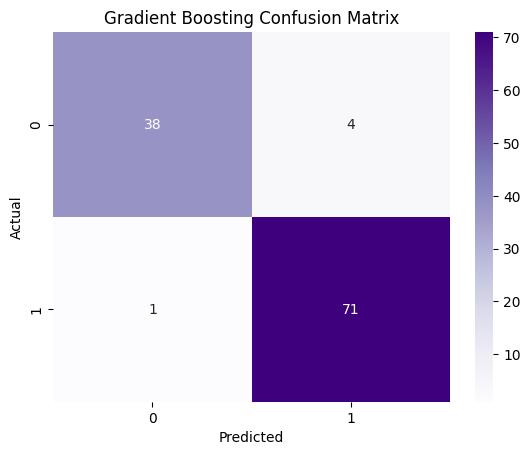

In [4]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Purples")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

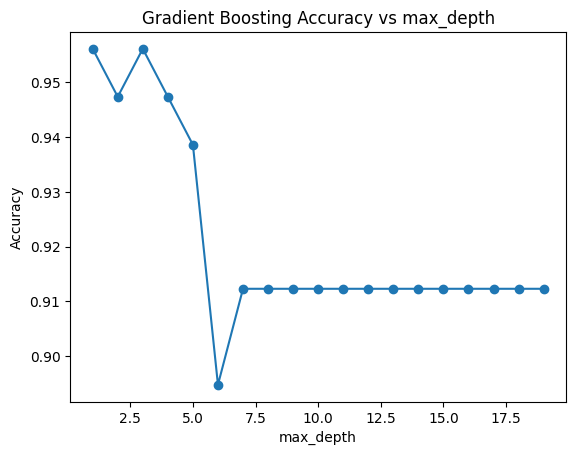

In [5]:
depths = range(1,20)
scores = []

for d in depths:
    gb_temp = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=d, random_state=42)
    gb_temp.fit(X_train, y_train)
    y_pred = gb_temp.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

plt.plot(depths, scores, marker='o')
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting Accuracy vs max_depth")
plt.show()

Top 10 fontos feature:
worst radius            0.435500
worst perimeter         0.271483
worst concave points    0.106549
worst texture           0.052638
mean concave points     0.030458
texture error           0.026927
worst area              0.022313
worst concavity         0.010819
worst smoothness        0.010706
area error              0.005348
dtype: float64


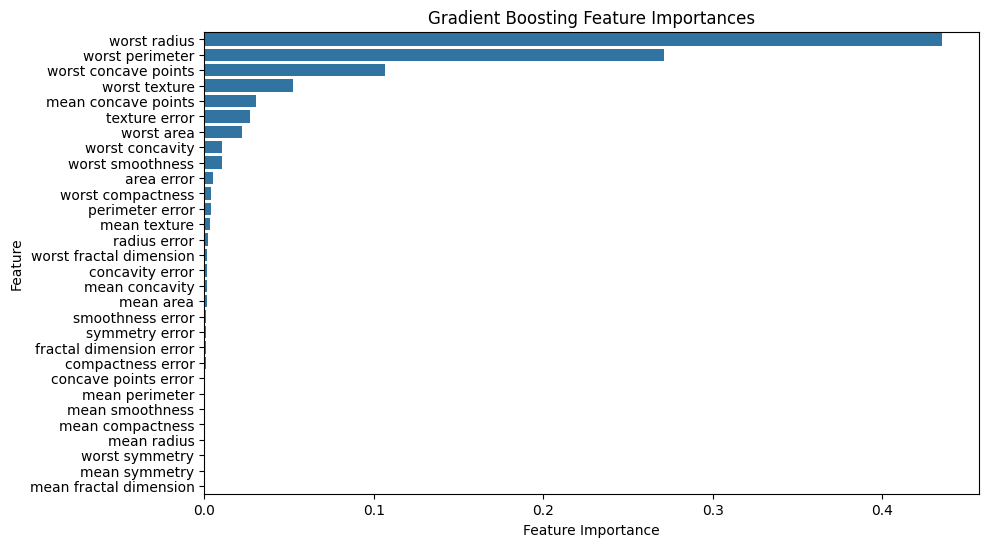

In [8]:
# Feature fontosságok kiírása és rendezése
importances = pd.Series(gb.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("Top 10 fontos feature:")
print(importances.head(10))

# Vizualizáció
plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importances")
plt.show()